#Logistic Regression From Scratch.

Implemented using **NumPy** — **Pandas** and **Matplotlib** are just for data setup and visualization.

In this notebook we implement **Logistic Regression from scratch**, covering:
- What logistic regression is and when to use it
- The **Sigmoid Function** — turning raw scores into probabilities
- The **Binary Cross-Entropy Loss** — measuring how wrong we are
- **Gradient Descent** — optimizing our parameters
- A clean, reusable `LogisticRegression` class

Resources that helped me build this:

Video 1 — Intuition: https://youtu.be/yIYKR4sgzI8?si=MP73cuObel0sGMKN

Video 2 — Implementation: https://youtu.be/Jj7WD71qQWE?si=QPHpUg3NlOOOwy33

Kaggle Reference: https://www.kaggle.com/code/fareselmenshawii/logistic-regression-from-scratch



## What is Logistic Regression?

Unlike **Linear Regression**, which predicts a continuous value, **Logistic Regression** is used for **binary classification** — it predicts whether an input belongs to class `0` or class `1`.

Instead of fitting a line, we fit a **sigmoid curve** that squashes our raw output into a probability between 0 and 1:

$$P(y=1 \mid x) = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}$$

where:
- $\mathbf{x}$ → input feature vector
- $\mathbf{w}$ → weight vector (one weight per feature)
- $b$ → bias term
- $\sigma(z)$ → the sigmoid function

If the predicted probability is $\geq 0.5$, we predict class `1`; otherwise class `0`.

Let's start coding 🤓 .

## 1. Imports

In [1]:
import numpy as np          # all the math - matrix ops
import pandas as pd          # loading and exploring our data
import matplotlib.pyplot as plt  # visualization

## 2. Initialize Data

We generate a synthetic binary classification dataset using **NumPy** .

We create two clusters of points:
- **Class 0** — centered around `(-1, -1)`
- **Class 1** — centered around `(+1, +1)`

We then package everything into a **Pandas DataFrame** for a clean look at the data.

In [2]:
np.random.seed(42)

m = 500          # number of training examples
n = 2            # number of features

# --- create two separable clusters
X_class0 = np.random.randn(m // 2, n) - 1   # cluster around (-1, -1)
X_class1 = np.random.randn(m // 2, n) + 1   # cluster around (+1, +1)

X_train = np.vstack([X_class0, X_class1])           # shape (m, n)
y_train = np.hstack([np.zeros(m // 2), np.ones(m // 2)])  # shape (m,)

df = pd.DataFrame(X_train, columns=["feature1", "feature2"])
df["label"] = y_train.astype(int)

print(f"Dataset shape: {df.shape}")
print(df.head())

Dataset shape: (500, 3)
   feature1  feature2  label
0 -0.503286 -1.138264      0
1 -0.352311  0.523030      0
2 -1.234153 -1.234137      0
3  0.579213 -0.232565      0
4 -1.469474 -0.457440      0


## 3. Visualize the Data

Before training anything, it's always good to **look at the data**.

We scatter-plot both features, coloring each point by its class label.

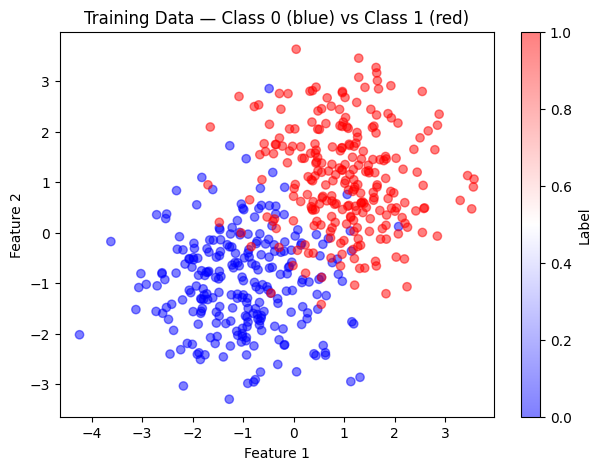

In [3]:
plt.figure(figsize=(7, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="bwr", alpha=0.5)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training Data — Class 0 (blue) vs Class 1 (red)")
plt.colorbar(label="Label")
plt.show()

## 4. The Sigmoid Function

The **sigmoid function** maps any real number $z$ to a value in $(0, 1)$:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

This is what lets us interpret the model's raw output as a **probability**.

- When $z \to +\infty$, $\sigma(z) \to 1$
- When $z \to -\infty$, $\sigma(z) \to 0$
- When $z = 0$, $\sigma(z) = 0.5$

In [4]:
def sigmoid(z):
    """
    Sigmoid activation function.
    Works element-wise on scalars, vectors, and matrices.
    """
    return 1 / (1 + np.exp(-z))

## 5. The Cost Function — Binary Cross-Entropy Loss

We can't use Mean Squared Error here — it produces a **non-convex** surface for Logistic Regression.

Instead we use **Binary Cross-Entropy** (also called Log Loss):

$$J(w, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

where:
- $m$ → number of training examples
- $\hat{y}^{(i)} = \sigma(\mathbf{w}^T \mathbf{x}^{(i)} + b)$ → predicted probability for sample $i$
- $y^{(i)}$ → true label (0 or 1) for sample $i$

The key insight: when $y=1$, we want $\hat{y}$ close to 1; when $y=0$, we want $\hat{y}$ close to 0.
Cross-entropy heavily penalizes confident wrong predictions.

In [5]:
def compute_cost(X, y, w, b):
    """
    Binary Cross-Entropy (Log Loss).

    X : (m, n) feature matrix
    y : (m,)   true labels
    w : (n,)   weights
    b : float  bias
    """
    m = len(y)
    z     = X @ w + b            # (m,)  raw scores
    y_pred = sigmoid(z)           # (m,)  predicted probabilities

    # clip to avoid log(0)
    ypred = np.clip(y_pred, 1e-15, 1 - 1e-15)

    cost = -(1 / m) * np.sum(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
    return cost

## 6. The Gradient Function

To minimize the cost, we need its **partial derivatives** with respect to $w$ and $b$:

$$\frac{\partial J}{\partial w} = \frac{1}{m} X^T (\hat{y} - y)$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})$$

These are the directions we'll step in (negated) to reduce the cost.


In [6]:
def compute_gradients(X, y, w, b):
    """
    Computes dw and db for one gradient step.

    X : (m, n) feature matrix
    y : (m,)   true labels
    w : (n,)   weights
    b : float  bias
    """
    m     = len(y)
    z     = X @ w + b            # (m,)
    error = sigmoid(z) - y       # (m,)  prediction error

    dw = (1 / m) * (X.T @ error)   # (n,)
    db = (1 / m) * np.sum(error)   # scalar

    return dw, db

## 7. The LogisticRegression Class

We now package everything into a clean `LogisticRegression` class — mirroring the structure used in the Linear Regression notebook.

It:
1. Initializes $w$ to zeros and $b$ to 0
2. Runs the gradient descent loop for `epochs` iterations
3. At each step: computes the cost → computes the gradients → updates $w$ and $b$
4. Tracks cost over time so we can plot the **learning curve**
5. Exposes a `predict` method that returns binary class labels

In [7]:
class LogisticRegression:
    def __init__(self, lr=0.1, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0.0
        self.cost_history = []

    def fit(self, X, y):
        """Train the model using gradient descent."""
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0.0
        self.cost_history = []

        for epoch in range(self.epochs):
            dw, db = compute_gradients(X, y, self.w, self.b)
            self.w -= self.lr * dw
            self.b -= self.lr * db

            cost = compute_cost(X, y, self.w, self.b)
            self.cost_history.append(cost)

            if epoch % 100 == 0:
                print(f"Epoch {epoch:4d} | Cost: {cost:.4f}")

        return self

    def predict_proba(self, X):
        """Return predicted probabilities (values in (0, 1))."""
        return sigmoid(X @ self.w + self.b)

    def predict(self, X, threshold=0.5):
        """Return binary class predictions (0 or 1)."""
        return (self.predict_proba(X) >= threshold).astype(int)

## 8. Train & Evaluate

We train a model on our synthetic dataset and check three things:
1. **Cost curve** — does the loss go down smoothly?
2. **Decision boundary** — does the learned line separate the two classes?
3. **Training accuracy** — how many samples did we classify correctly?

In [8]:
model = LogisticRegression(lr=0.5, epochs=500)
model.fit(X_train, y_train)

predictions = model.predict(X_train)
accuracy    = np.mean(predictions == y_train) * 100
print(f"\nTraining accuracy: {accuracy:.2f}%")

Epoch    0 | Cost: 0.4832
Epoch  100 | Cost: 0.1807
Epoch  200 | Cost: 0.1797
Epoch  300 | Cost: 0.1796
Epoch  400 | Cost: 0.1796

Training accuracy: 92.20%


## 9. Visualize Results

### Cost Curve
Confirms that gradient descent is converging — the loss should decrease monotonically.

### Decision Boundary
The decision boundary is the line where the predicted probability equals 0.5, i.e.:

$$\mathbf{w}^T \mathbf{x} + b = 0$$

Solving for `feature2`:
$$\text{feature}_2 = -\frac{w_1 \cdot \text{feature}_1 + b}{w_2}$$

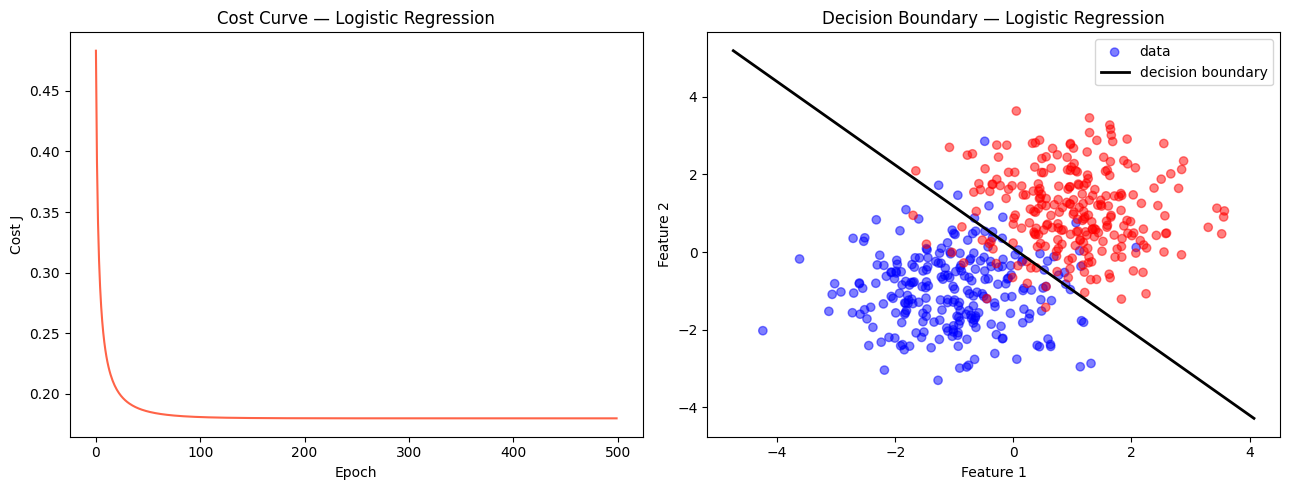

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Cost Curve ---
axes[0].plot(model.cost_history, color="tomato")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cost J")
axes[0].set_title("Cost Curve — Logistic Regression")

# --- Plot 2: Decision Boundary ---
x1_min, x1_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
x1_line = np.linspace(x1_min, x1_max, 200)
x2_line = -(model.w[0] * x1_line + model.b) / model.w[1]

axes[1].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="bwr", alpha=0.5, label="data")
axes[1].plot(x1_line, x2_line, color="black", linewidth=2, label="decision boundary")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].set_title("Decision Boundary — Logistic Regression")
axes[1].legend()

plt.tight_layout()
plt.show()